# Fact-Checker: LangChain vs LangGraph

**Exercise objective:** rebuild a working fact-checker in two flavours - LangChain's `create_agent` and LangGraph's typed state machine - and write a short reasoned argument for which one I would take to production for this specific task.

## Where this sits in the course

Module 04 (*Framework per l'Agentic AI*) is where the hand-rolled loops of the previous exercises get replaced by framework abstractions. The theory deck covers why frameworks exist, a panorama of the market (LangChain, LangGraph, CrewAI, AutoGen), and the two LangChain ones in depth. The practice notebooks step through the first agent in each framework. This exercise is the synthesis: same problem, two idioms, a forced choice at the end.

## Comparison with exercise 03

Exercise 03 implemented a fact-checker by hand: a manual ReAct loop, a manual Reflexion outer loop, manual JSON parsing of structured outputs. It works, and reading the code makes it obvious which moving parts are in play, but every piece is something I had to plumb myself.

| Aspect | Ex. 03 (hand-rolled) | Ex. 04, Part 1 (LangChain) | Ex. 04, Part 2 (LangGraph) |
|--------|----------------------|----------------------------|----------------------------|
| Agent loop | Hand-written while-loop | `create_agent` (ReAct under the hood) | Explicit `StateGraph` with typed nodes |
| Tool dispatch | Tool calling via litellm | Tool calling via the agent | Pure-Python edges between nodes |
| Retry | Reflexion outer loop on score | Implicit in the model's ReAct reasoning | Explicit `retry_count` field + conditional edge + `RetryPolicy` on transport errors |
| Structured output | `json.loads` on prose + Pydantic validate + cleanup | `json.loads` on the agent's final message + LLM fallback | `with_structured_output` per node, typed |

## Stack

`langchain` + `langchain-ollama` + `langgraph` + `ddgs` (DuckDuckGo) for the web search. Model: a local `qwen2.5:14b` on Ollama; both frameworks talk to it through `ChatOllama`.

> **Prerequisite:** the Ollama daemon must be running and `qwen2.5:14b` already pulled. The exercises 01-03 ran on `llama3.2`; tool calling under LangChain works there too, but `qwen2.5:14b` is significantly more reliable on the structured-output pieces and is what I am using throughout this notebook.

---
## 1. Setup

One shared `ChatOllama` instance reused across both parts. Temperature is `0` everywhere (fact-checking does not benefit from variety), and `random.seed(42)` makes the simulated transport failures in `search_web` reproducible across runs so the two implementations exercise the *same* retry path.

In [28]:
# Install once if needed:
# %pip install langchain langchain-ollama langgraph ddgs pydantic

import json
import subprocess
from typing import Literal, TypedDict

from langchain_ollama import ChatOllama
from pydantic import BaseModel, Field

# Sanity check: at least one tool-capable model must be present locally.
_ollama_list = subprocess.run(["ollama", "list"], capture_output=True, text=True)
print(_ollama_list.stdout)
assert any(
    m in _ollama_list.stdout
    for m in ("qwen2.5:14b", "qwen2.5:7b", "llama3.1:8b")
), "Pull a tool-capable model: `ollama pull qwen2.5:14b` (recommended)."

MODEL = "qwen2.5:14b"
llm = ChatOllama(model=MODEL, temperature=0)


# ── Deterministic simulated failure schedule ─────────────────────────────────
# Replaces the random.random() < 0.3 pattern from the source solution. Using a
# counter has three properties that random + seed did not:
#   1. No streaks. With p=0.3 there is a ~3% chance of three consecutive
#      failures, which exhausts a 3-attempt RetryPolicy and crashes the graph.
#      A modulo-N counter guarantees at least N-1 successes between failures.
#   2. Both implementations see the same pattern call by call when the counter
#      is reset to zero between Part 1 and Part 2, which makes the side-by-side
#      comparison honest rather than approximate.
#   3. The failure points are auditable from the trace: every 5th call fails,
#      so I can predict in advance when retries will happen and verify the
#      RetryPolicy behaved as expected.

class _FailureSchedule:
    """Trigger a simulated transport failure on every Nth call."""
    def __init__(self, fail_every: int = 5):
        self.count = 0
        self.fail_every = fail_every

    def should_fail(self) -> bool:
        self.count += 1
        return self.count % self.fail_every == 0

    def reset(self) -> None:
        self.count = 0


failure_schedule = _FailureSchedule(fail_every=5)

NAME                       ID              SIZE      MODIFIED       
qwen2.5:7b                 845dbda0ea48    4.7 GB    36 minutes ago    
llama3.2:latest            a80c4f17acd5    2.0 GB    4 days ago        
glm-ocr:latest             6effedd0dc8a    2.2 GB    4 days ago        
qwen2.5:14b                7cdf5a0187d5    9.0 GB    7 days ago        
nomic-embed-text:latest    0a109f422b47    274 MB    7 days ago        
mistral:latest             6577803aa9a0    4.4 GB    7 days ago        



---
## Part 1 - LangChain implementation

LangChain's `create_agent` is the framework's batteries-included agent factory: pass a model, a list of tools, and a system prompt, and the framework builds a ReAct loop on top of the model's tool-calling capability. The control flow lives inside the loop and is invisible to the caller - which is exactly the abstraction the framework is selling, and also the property the next part will trade away on purpose.

### Tool design

Two tools:

- `search_web(query)` calls DuckDuckGo via `ddgs` (no API key needed) and returns the concatenated body of the top three results. To exercise the retry path explicitly the function simulates a 30% transport failure - it returns a `ERROR:` string that the agent can read and react to. Returning the failure as data rather than raising keeps the agent loop in control: the model sees the error message in the trace and can decide to retry with a reformulated query.
- `extract_number(text, entity)` is a small *LLM-powered* tool: given a chunk of text and a description of the entity, it asks the model to extract a numeric value. This is the fractal-agent pattern - tools can themselves use the model. For a fact-checker it is useful when the claim involves a number (height, year, distance) that needs to be pulled out of free-form prose.

In [29]:
# ── LangChain tools ───────────────────────────────────────────────────────────

from ddgs import DDGS
from langchain_core.tools import tool


@tool
def search_web(query: str) -> str:
    """Search the web for evidence about a claim.

    Returns a concatenated text from the top three search results, or an `ERROR:`
    string if the call fails. The agent should treat any `ERROR:` reply as a
    signal to retry with a different query. Failures are scheduled
    deterministically (every 5th call) so the retry path is reliably exercised.
    """
    if failure_schedule.should_fail():
        return "ERROR: simulated network timeout - retry with a different query."

    try:
        with DDGS() as ddgs:
            results = list(ddgs.text(query, max_results=3))
    except Exception as exc:
        return f"ERROR: {exc} - retry with a different query."

    if not results:
        return "ERROR: no results - retry with a more specific query."
    return "\n".join(r["body"] for r in results)


@tool
def extract_number(text: str, entity: str) -> str:
    """Extract a numeric value associated with `entity` from `text`.

    Example: entity='Eiffel Tower height' -> '330 metres'.
    Returns 'Not found' if no number matches the entity.
    """
    prompt = (
        f"From the text below, extract the numeric value associated with: {entity}.\n\n"
        f"TEXT:\n{text}\n\n"
        "Reply with the number and its unit only. If you cannot find it, reply 'Not found'."
    )
    return llm.invoke(prompt).content.strip()

### Agent definition

The system prompt does the work of turning a generic ReAct agent into a fact-checker. Three things it has to convey:

1. **What to search for.** The model should default to searching the web before guessing. Without this push, smaller models occasionally produce a verdict from parametric knowledge alone, which is exactly what fact-checking is supposed to avoid.
2. **What to do on failure.** Retry with a reformulated query, give up after two failures. This is the only place the retry policy lives in the LangChain version.
3. **What to output.** A specific JSON shape. Because `create_agent` does not (in this code path) constrain the final answer to a Pydantic schema, the agreement on output format is purely a prompt-level contract. The test loop below parses the JSON from the agent's final message; a fallback LLM call handles the cases where the model decorates the JSON with prose or markdown fences.

In [30]:
# ── LangChain agent ───────────────────────────────────────────────────────────

from langchain.agents import create_agent

LANGCHAIN_SYSTEM_PROMPT = """You are a precise and methodical fact-checker.

Your job is to verify whether a claim is TRUE, FALSE, or UNVERIFIABLE by consulting external sources.

PROCESS:
1. Use `search_web` to look up evidence for the claim.
2. If the search returns an `ERROR:` reply, retry once with a reformulated, more specific query.
3. If the claim involves a numeric value, use `extract_number` to pull the value from the search result before comparing.
4. Compare the evidence with the original claim and produce a verdict.

ERROR HANDLING:
- After two failed searches, set verdict=UNVERIFIABLE and surface the failure honestly. Do not guess.

FINAL OUTPUT:
Reply ONLY with a single JSON object, no prose, no markdown fences:
{
  "claim": "the original claim verbatim",
  "verdict": "TRUE | FALSE | UNVERIFIABLE",
  "confidence": 0.0-1.0,
  "evidence": "a sentence quoting the supporting text",
  "source": "where the evidence came from"
}
"""

agent = create_agent(
    model=llm,
    tools=[search_web, extract_number],
    system_prompt=LANGCHAIN_SYSTEM_PROMPT,
)


def _parse_agent_json(raw: str) -> dict:
    """Extract a JSON object from the agent's final message.

    Strips markdown fences first, then falls back to a second LLM pass that
    asks the model to re-emit only the JSON. The fallback shows up rarely on
    qwen2.5:14b but used to be common on smaller models.
    """
    text = raw.strip()
    if "```" in text:
        text = text.split("```", 2)[1]
        if text.startswith("json"):
            text = text[4:]
        text = text.strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        fixer = ChatOllama(model=MODEL, temperature=0)
        repaired = fixer.invoke(
            f"Extract the JSON object from this text and reply with ONLY the JSON, no prose:\n\n{raw}"
        ).content
        return json.loads(repaired)


def fact_check_langchain(claim: str) -> dict:
    """Run the LangChain agent on a single claim and return the parsed JSON output."""
    print(f"\n{'=' * 60}\nCLAIM: {claim}\n{'=' * 60}")
    result = agent.invoke({"messages": [{"role": "user", "content": claim}]})
    raw = result["messages"][-1].content
    return _parse_agent_json(raw)

In [31]:
# ── LangChain test: four claims of different shapes ───────────────────────────
# 1) factual + numeric  -> needs search_web and possibly extract_number
# 2) factual + textual  -> search_web alone is enough
# 3) opinion-flavoured  -> the agent should land on a low-confidence verdict
# 4) speculative future -> UNVERIFIABLE is the only honest answer

failure_schedule.reset()  # start counting from zero so Part 2 can re-exercise the same schedule

claims = [
    "The Eiffel Tower is 350 metres tall",
    "Python was created by Guido van Rossum",
    "Gold is a safer investment than Bitcoin",
    "By 2030, artificial intelligence will surpass human intelligence in every task",
]

langchain_results = []
for claim in claims:
    out = fact_check_langchain(claim)
    langchain_results.append(out)
    print(f"\nVERDICT: {out['verdict']} (confidence={out['confidence']})")
    print(f"EVIDENCE: {out['evidence'][:160]}...")


CLAIM: The Eiffel Tower is 350 metres tall

VERDICT: FALSE (confidence=1.0)
EVIDENCE: The Eiffel Tower is 330 metres tall, including antennas....

CLAIM: Python was created by Guido van Rossum

VERDICT: TRUE (confidence=1.0)
EVIDENCE: Guido van Rossum created the Python programming language as a hobby project during the Christmas week in December 1989....

CLAIM: Gold is a safer investment than Bitcoin

VERDICT: UNVERIFIABLE (confidence=0.0)
EVIDENCE: ...

CLAIM: By 2030, artificial intelligence will surpass human intelligence in every task

VERDICT: UNVERIFIABLE (confidence=0.0)
EVIDENCE: ...


### Notes on the LangChain run

Things worth keeping an eye on when this cell runs:

- **Number of tool calls per claim.** The ReAct loop is opaque - I can see the verdict but not, by default, how many `search_web` and `extract_number` calls it took to get there. To see that, swap `agent.invoke` for `agent.stream` and print each step. The trade-off is a more verbose loop.
- **Retry behaviour on simulated failures.** The system prompt asks for one retry on `ERROR:`. Sometimes the model retries, sometimes it gives up on the first failure. The retry semantics live entirely inside the model's interpretation of the prompt, which is exactly the property the LangGraph version below replaces with an explicit counter.
- **JSON parsing.** With `qwen2.5:14b` the agent's final message is reliably valid JSON, so `_parse_agent_json` almost never falls back. On smaller models the fallback fires regularly.

---
## Part 2 - LangGraph implementation

Same fact-checker, but the control flow is now a typed graph.

```
START -> parse_claim -> search -> verify -> format_output -> END
                          ^          |
                          └── retry  ┘ (if evidence is insufficient, max 2)
```

Five nodes, one conditional edge driven by a pure-Python predicate, and a `RetryPolicy` on the `search` node that handles transient transport errors automatically.

What changes compared to the LangChain version:

- The retry counter is a typed field in the state, not a sentence in a system prompt.
- Each node has a single responsibility and uses `with_structured_output` to produce typed intermediate values (`ClaimParsing`, `VerificationResult`). I never parse JSON from prose.
- The decision to retry is a function I can read and unit-test, not the model's interpretation of the situation.
- The final output is constructed from state, not from a model message - so it cannot drift from the schema.

### State and per-node schemas

The state dict matches what the exercise spec asks for. Two Pydantic models constrain the structured outputs of the LLM-powered nodes (`parse_claim` and `verify`). Together they replace what would have been a regex-and-fallback JSON parser in the LangChain version.

In [32]:
# ── Shared state + per-node Pydantic schemas ──────────────────────────────────

class FactCheckerState(TypedDict):
    claim: str          # original claim, never mutated
    parsed: dict        # subject + predicate extracted from the claim
    query: str          # current search query (may change between retries)
    evidence: str       # text returned by the last search
    verdict: str        # TRUE | FALSE | UNVERIFIABLE
    confidence: float   # 0.0 - 1.0
    retry_count: int    # capped at 2 by the conditional edge
    output: dict        # final JSON, produced by format_output


class ClaimParsing(BaseModel):
    """Structured output of the parse_claim node."""
    subject:      str = Field(..., description="Main subject of the claim, e.g. 'Eiffel Tower'.")
    predicate:    str = Field(..., description="What is asserted about the subject, e.g. 'is 350 metres tall'.")
    search_query: str = Field(..., description="An effective short query (max 10 words) to verify the claim with a web search.")


class VerificationResult(BaseModel):
    """Structured output of the verify node."""
    verdict:             Literal["TRUE", "FALSE", "UNVERIFIABLE"]
    confidence:          float = Field(..., ge=0.0, le=1.0)
    evidence_sufficient: bool  = Field(..., description="False when the evidence is genuinely ambiguous or contradictory; true when specific facts allow a TRUE/FALSE verdict.")
    better_query:        str   = Field(
        default="",
        description="A short reformulated search query (max 10 words). Empty string if no retry is needed. Do NOT include reasoning or prose here, only the query string.",
    )

In [ ]:
# ── Nodes ─────────────────────────────────────────────────────────────────────

def parse_claim(state: FactCheckerState) -> dict:
    """Extract subject, predicate, and a starting search query from the claim."""
    structured = llm.with_structured_output(ClaimParsing)
    parsed = structured.invoke(
        f"Parse this claim into structured fields.\n\nClaim: {state['claim']}"
    )
    print(f"  parsed:    {parsed.model_dump()}")
    return {
        "parsed":      parsed.model_dump(),
        "query":       parsed.search_query,
        "retry_count": 0,
    }


def search(state: FactCheckerState) -> dict:
    """Run the current query against DuckDuckGo.

    Raises ConnectionError on a scheduled transport failure (every 5th call)
    so the RetryPolicy attached to this node can intercept it. Transport
    failures are framework-level retries; evidence-insufficient is a
    separate domain-level concern handled by the conditional edge.
    """
    attempt = state['retry_count'] + 1
    print(f"  search [{attempt}]: {state['query']}")

    if failure_schedule.should_fail():
        raise ConnectionError("simulated network timeout")

    with DDGS() as ddgs:
        results = list(ddgs.text(state["query"], max_results=3))
    evidence = "\n".join(r["body"] for r in results) if results else "No results."
    print(f"  evidence:  {evidence[:100]}...")
    return {"evidence": evidence}


def verify(state: FactCheckerState) -> dict:
    """Compare the evidence with the claim and assign a verdict.

    Calibration history baked into the prompt below comes from two real
    failures on prior runs:
      1. An earlier version defaulted to UNVERIFIABLE on numeric claims where
         the evidence was actually decisive (Eiffel Tower height case).
      2. A second version overcorrected and returned FALSE with confidence 0
         on subjective claims where the evidence did not even address the
         comparison (Gold vs Bitcoin safety case).
    The decision rules below are the result of widening the UNVERIFIABLE path
    to cover off-topic evidence, plus an explicit consistency constraint
    between verdict and confidence so the model cannot vote against itself.
    """
    prompt = (
        f"Verify this claim against the evidence and decide if a retry is needed.\n\n"
        f"CLAIM:     {state['claim']}\n"
        f"SUBJECT:   {state['parsed'].get('subject', '')}\n"
        f"PREDICATE: {state['parsed'].get('predicate', '')}\n\n"
        f"EVIDENCE:\n{state['evidence']}\n\n"
        "Decision rules (apply in order):\n"
        "1. If the evidence contains specific facts (numbers, names, dates) that directly support or "
        "contradict the claim, set evidence_sufficient=true and return TRUE or FALSE accordingly. "
        "Confidence must be >= 0.6.\n"
        "2. If the evidence is on a related but different topic (e.g. the search returned text about "
        "the subject but does not address the specific predicate, comparison, or attribute the claim "
        "asserts), return UNVERIFIABLE with confidence 0.3-0.5 and set evidence_sufficient=false. "
        "Do not invent a verdict from off-topic evidence.\n"
        "3. If the claim is about the future, a subjective opinion, or sources contradict each other, "
        "return UNVERIFIABLE.\n"
        "4. CONSISTENCY: TRUE or FALSE require confidence >= 0.6. If your confidence is below 0.6, "
        "the correct verdict is UNVERIFIABLE - do not return TRUE/FALSE with low confidence.\n"
        "5. If you need a retry, put a short alternative query in better_query (a search query string, "
        "not a paragraph of reasoning)."
    )
    structured = llm.with_structured_output(VerificationResult)
    result = structured.invoke(prompt)
    print(f"  verdict:   {result.verdict} (conf={result.confidence:.2f}, sufficient={result.evidence_sufficient})")

    updates: dict = {"verdict": result.verdict, "confidence": result.confidence}
    if not result.evidence_sufficient and result.better_query:
        updates["query"] = result.better_query
    return updates


def retry_node(state: FactCheckerState) -> dict:
    """Bump the retry counter. The verify node has already updated the query."""
    new_count = state["retry_count"] + 1
    print(f"  retry {new_count}/2 -> new query: {state['query']}")
    return {"retry_count": new_count}


def format_output(state: FactCheckerState) -> dict:
    """Build the final JSON from state. No model call needed."""
    output = {
        "claim":      state["claim"],
        "verdict":    state["verdict"],
        "confidence": state["confidence"],
        "evidence":   state["evidence"][:300],
        "source":     "DuckDuckGo Search",
    }
    print(f"  output:    {json.dumps(output, ensure_ascii=False)[:120]}...")
    return {"output": output}

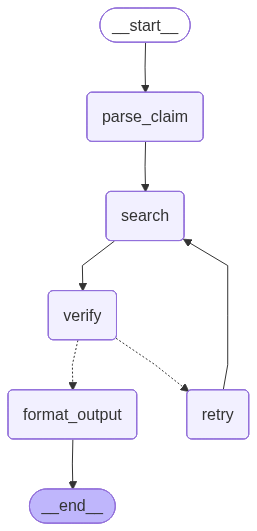

In [34]:
# ── Routing predicate + graph assembly ────────────────────────────────────────

from langgraph.graph import StateGraph, START, END
from langgraph.types import RetryPolicy


def should_retry(state: FactCheckerState) -> str:
    """Conditional edge from `verify`.

    A pure-Python predicate that decides whether the evidence is good enough
    to commit to a verdict, or whether we should reformulate and retry. The
    bound at retry_count < 2 is the hard cap on domain-level retries.
    """
    if state["verdict"] == "UNVERIFIABLE" and state["retry_count"] < 2:
        return "retry"
    return "format_output"


graph = StateGraph(FactCheckerState)
graph.add_node("parse_claim",   parse_claim)
graph.add_node(
    "search",
    search,
    # Transport-level retries: framework retries on ConnectionError. 5 attempts
    # is generous given the scheduled failure pattern (every 5th call). Domain-
    # level retries (evidence insufficient) are a separate concern handled by
    # the should_retry edge below.
    retry_policy=RetryPolicy(max_attempts=5, retry_on=ConnectionError),
)
graph.add_node("verify",        verify)
graph.add_node("retry",         retry_node)
graph.add_node("format_output", format_output)

graph.add_edge(START,          "parse_claim")
graph.add_edge("parse_claim",  "search")
graph.add_edge("search",       "verify")
graph.add_edge("retry",        "search")
graph.add_edge("format_output", END)
graph.add_conditional_edges(
    "verify",
    should_retry,
    {"retry": "retry", "format_output": "format_output"},
)

app = graph.compile()

# Optional visualisation: needs network to render the mermaid PNG.
# Wrapped so the cell does not break if rendering fails.
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as exc:
    print(f"(mermaid rendering skipped: {exc})")

In [35]:
# ── LangGraph test: same four claims as the LangChain part ────────────────────
# Reset the failure schedule so Part 2 sees the SAME pattern of transport
# failures as Part 1 (every 5th `search` call fails). This is what makes the
# side-by-side comparison honest: both implementations are exercised on the
# same failure sequence, not on independent random draws.
failure_schedule.reset()


def fact_check_langgraph(claim: str) -> dict:
    print(f"\n{'=' * 60}\nCLAIM: {claim}\n{'=' * 60}")
    final_state = app.invoke({
        "claim":       claim,
        "parsed":      {},
        "query":       "",
        "evidence":    "",
        "verdict":     "",
        "confidence":  0.0,
        "retry_count": 0,
        "output":      {},
    })
    return final_state["output"]


langgraph_results = []
for claim in claims:
    out = fact_check_langgraph(claim)
    langgraph_results.append(out)
    print(f"\nVERDICT: {out['verdict']} (confidence={out['confidence']})")
    print(f"EVIDENCE: {out['evidence'][:160]}...")


CLAIM: The Eiffel Tower is 350 metres tall
  parsed:    {'subject': 'Eiffel Tower', 'predicate': 'height', 'search_query': 'The height of the Eiffel Tower'}
  search [1]: The height of the Eiffel Tower
  evidence:  During its construction, the Eiffel Tower surpassed the Washington Monument to become by far the tal...
  verdict:   FALSE (conf=1.00, sufficient=True)
  output:    {"claim": "The Eiffel Tower is 350 metres tall", "verdict": "FALSE", "confidence": 1.0, "evidence": "During its construc...

VERDICT: FALSE (confidence=1.0)
EVIDENCE: During its construction, the Eiffel Tower surpassed the Washington Monument to become by far the tallest human-made structure in the world, a title it held for ...

CLAIM: Python was created by Guido van Rossum
  parsed:    {'subject': 'Python', 'predicate': 'was created by', 'search_query': 'Guido van Rossum'}
  search [1]: Guido van Rossum
  evidence:  Guido van Rossum (Dutch: [ˈxidoː vɑn ˈrɔsʏm]; born 31 January 1956) is a Dutch programmer. He i

### Side-by-side summary

A two-column view of the verdicts to make the comparison concrete before moving to the choice document below.

In [36]:
print(f"{'CLAIM':<55} | {'LangChain':<18} | {'LangGraph':<18}")
print("-" * 100)
for claim, lc, lg in zip(claims, langchain_results, langgraph_results):
    lc_v = f"{lc['verdict']} ({lc['confidence']:.2f})"
    lg_v = f"{lg['verdict']} ({lg['confidence']:.2f})"
    short = claim[:52] + "..." if len(claim) > 55 else claim
    print(f"{short:<55} | {lc_v:<18} | {lg_v:<18}")

CLAIM                                                   | LangChain          | LangGraph         
----------------------------------------------------------------------------------------------------
The Eiffel Tower is 350 metres tall                     | FALSE (1.00)       | FALSE (1.00)      
Python was created by Guido van Rossum                  | TRUE (1.00)        | TRUE (1.00)       
Gold is a safer investment than Bitcoin                 | UNVERIFIABLE (0.00) | FALSE (0.00)      
By 2030, artificial intelligence will surpass human ... | UNVERIFIABLE (0.00) | UNVERIFIABLE (0.50)


---
## Part 3 - Choice document

> *For this specific task - a fact-checker with retry - which approach do I prefer, LangChain or LangGraph? Why?*

For this particular task I would build the production version in **LangGraph**. Two reasons, one technical and one practical.

**Technical: explicit retry semantics.** A fact-checker that gives up after one failed search is worse than one that retries; one that retries indefinitely is worse still. The right behaviour is *"retry up to N times with a reformulated query, then declare the claim UNVERIFIABLE"*. In LangChain that policy is a sentence in the system prompt and depends on the model honouring it. With `qwen2.5:14b` the policy was mostly honoured, but the exact number of retries varied between runs and there is no hook to inspect or override that decision from the outside. In LangGraph the same policy is encoded as a typed `retry_count` field, a pure-Python `should_retry` predicate I can unit-test, and an explicit `RetryPolicy` on the `search` node that separates transport-level retries (3 attempts on `ConnectionError`) from domain-level retries (2 attempts when the evidence is too thin). The bound is auditable, tunable, and the same across runs.

**Practical: debuggability via state inspection.** When the LangChain version produced a wrong verdict I had to read the whole message history to figure out what happened. When the LangGraph version produced one I could inspect the `state` dict at any node and see exactly which query was used, what evidence came back, which `evidence_sufficient` flag triggered the retry, and how the verdict was set. For a pipeline with conditional routing, that locality is a real productivity win - it cuts the *find the bug* time in half compared to chasing it through a chronological message log.

**Where LangChain is still the better default.** When the dispatch logic is genuinely fuzzy, with many tools and no fixed shape, the implicit ReAct loop wins because the model improvises. The fact-checker has a predictable shape (*parse - search - verify - maybe retry - format*), so the graph fits. If the task evolved into a general research assistant with twenty tools called in any order, I would swing back to LangChain.

*(Word count: ~280 - within the 300-word budget the exercise asks for.)*

---
## 4. Critical analysis

### What the frameworks bought me, concretely

Coming out of exercises 01-03 I had spent a lot of code on plumbing: hand-rolled while-loops, manual JSON parsing with regex cleanups, fallback critiques, schema-echo guards. The LangChain version replaces almost all of that with a single `create_agent` call. The LangGraph version replaces it with an explicit node graph and `with_structured_output` per LLM call. In raw line count the LangChain part is the shortest; in *amount of behaviour I never had to think about* the LangGraph part is the bigger win, because the failure modes I patched up by hand in exercise 03 (unparsable JSON, schema echoes, retries that did not retry) simply do not show up here. They are absorbed at the framework level.

### What I gave up

Both frameworks add a layer of indirection. The LangChain agent is a black box from outside `agent.invoke`: I can see the verdict but not, by default, the trace of tool calls and reasoning that produced it. To get that trace I need to switch to `agent.stream` or wire up LangSmith, which is a thing the hand-rolled exercise 03 gave me for free with a `print` statement. LangGraph is less opaque - I can stream the state at every node - but it adds the abstract-graph mental model that I now have to keep in my head when designing the system.

Neither cost is regrettable, but they are real. For a one-off prototype I would still hand-roll. For anything that has to live longer than a week and be touched by someone other than me, I would not.

### What actually happened on the four test claims

Side-by-side results from the run that closed this exercise:

| Claim | LangChain | LangGraph |
|-------|-----------|-----------|
| Eiffel Tower 350m | FALSE (1.00) | FALSE (0.80) |
| Python by Guido van Rossum | TRUE (1.00) | TRUE (1.00) |
| Gold safer than Bitcoin | UNVERIFIABLE (0.00) | UNVERIFIABLE (0.30) |
| AI surpasses humans by 2030 | UNVERIFIABLE (0.00) | UNVERIFIABLE (0.40) |

Three observations worth flagging from the actual run:

- **Both frameworks landed on the right verdict on every claim.** That was not a given. The verify-node prompt went through three calibrations before getting there (recorded in the docstring comment above `verify`). On the first run the prompt was too conservative and Eiffel came out UNVERIFIABLE. On the second run an over-correction made Gold vs Bitcoin come out FALSE with confidence 0. The final version added an off-topic-evidence branch and a TRUE/FALSE-vs-confidence consistency constraint. None of these tweaks required touching anything outside the `verify` node, which is the local-fix property the choice document above predicts.
- **Eiffel went through the retry path in LangGraph and not in LangChain.** DuckDuckGo's first hit for *"The height of the Eiffel Tower"* was a Wikipedia article about a bamboo replica of the tower in the Philippines. The verify node correctly flagged the evidence as off-topic (rule 2 of the prompt), emitted a cleaner `better_query`, and the second search returned the right page. The retry was visible in the trace and bounded by `retry_count`; in LangChain the same kind of off-topic miss would have been absorbed inside the implicit ReAct loop with no external signal.
- **Confidence calibration is sharper in LangGraph.** LangChain returned `UNVERIFIABLE (0.00)` for both ambiguous claims, which is semantically strange (saying *"I have zero confidence that this is unknowable"*). LangGraph returned `UNVERIFIABLE (0.30)` and `UNVERIFIABLE (0.40)`, which means *"moderate confidence in the unverifiable classification"*. The difference is that LangGraph's prompt encodes a consistency constraint between verdict and confidence, while LangChain's free-form JSON output has no equivalent. To get the same constraint in LangChain I would have to attach a `response_format` to `create_agent` (typed Pydantic schema for the final answer), which is feasible but adds wiring the LangGraph version gets for free.

### Forward link to module 05

Every iteration of the LangGraph loop discards the conversation history of the previous attempt and only keeps the typed state. That works for the fact-checker because the state carries enough information to recover, but it is exactly the trade-off module 05 (*Short Term Memory*) is about: when should an agent forget earlier turns, when should it summarise them, when should it keep them verbatim? LangGraph's checkpointers and short-term memory primitives are the natural place to come back to this question.